# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [232]:
import pandas as pd

In [233]:
train_fname = 'tweet_sentiment_train.csv.zip'
raw_df = pd.read_csv(train_fname)
raw_df.head(5)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on the releases we already bought","Sons of ****,",negative


In [234]:
print(raw_df.shape)
print(raw_df.info())
print(raw_df.isnull().sum())

(27481, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB
None
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64


In [235]:
raw_df.dropna(inplace=True)

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



<Axes: >

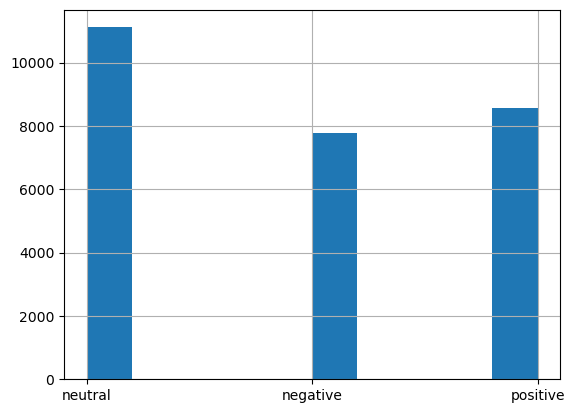

In [236]:
raw_df['sentiment'].hist()

<Axes: xlabel='text', ylabel='Count'>

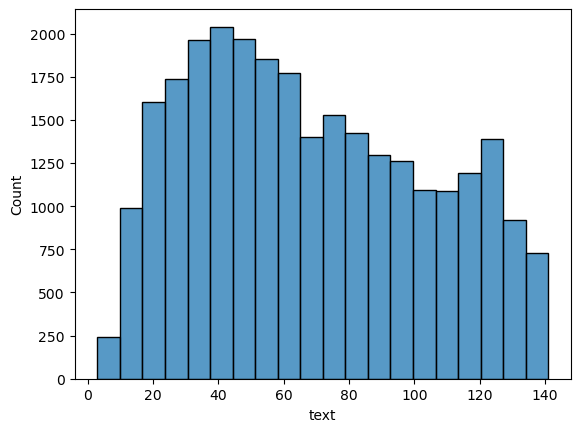

In [237]:
import seaborn as sns
sns.histplot(raw_df.text.str.len(), bins=20)

Найбільше постів довжиною  ~40, бачимо що постів довжиною 120-130 більше ніж довжиною 100

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [238]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import PunktSentenceTokenizer
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dasha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dasha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [239]:
sent_detector = PunktSentenceTokenizer()
stemmer = SnowballStemmer(language='english')
english_stopwords = stopwords.words('english')

In [240]:
def tokenize(text):
    return [stemmer.stem(word) for word in word_tokenize(text)]
def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in english_stopwords]

import re
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # прибираємо пунктуацію

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in english_stopwords]
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens

In [241]:
from collections import Counter

all_tokens = []

for text in raw_df["text"]:
    all_tokens.extend(preprocess(text))

word_freq = Counter(all_tokens)
word_freq.most_common(1000)

[('day', 2497),
 ('go', 2384),
 ('get', 1918),
 ('good', 1600),
 ('work', 1530),
 ('love', 1486),
 ('like', 1462),
 ('got', 1261),
 ('http', 1247),
 ('today', 1155),
 ('time', 1104),
 ('one', 1077),
 ('lol', 1029),
 ('happi', 1014),
 ('want', 991),
 ('thank', 991),
 ('u', 984),
 ('know', 980),
 ('miss', 968),
 ('back', 920),
 ('realli', 916),
 ('see', 905),
 ('com', 900),
 ('im', 887),
 ('think', 884),
 ('feel', 874),
 ('night', 819),
 ('hope', 807),
 ('mother', 797),
 ('make', 763),
 ('home', 750),
 ('new', 748),
 ('look', 727),
 ('well', 718),
 ('na', 711),
 ('need', 705),
 ('still', 689),
 ('oh', 683),
 ('much', 665),
 ('watch', 654),
 ('come', 635),
 ('great', 627),
 ('wish', 626),
 ('last', 605),
 ('morn', 592),
 ('twitter', 583),
 ('haha', 568),
 ('sad', 560),
 ('week', 556),
 ('fun', 541),
 ('tomorrow', 518),
 ('would', 515),
 ('say', 502),
 ('bad', 500),
 ('tri', 499),
 ('wait', 495),
 ('sleep', 495),
 ('follow', 495),
 ('thing', 494),
 ('sorri', 493),
 ('tonight', 490),
 ('fri

In [242]:
vectorizer = CountVectorizer(lowercase=True,
                             tokenizer=tokenize,
                             stop_words=english_stopwords,
                             max_features=2000)

In [243]:
vectorizer.fit(raw_df.text)

C:\Users\Dasha\AppData\Roaming\Python\Python313\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\Dasha\AppData\Roaming\Python\Python313\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function tok...002074F9728E0>
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['a', 'about', ...]"
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",

In [244]:
vectorizer.get_feature_names_out()[:100]

array(['!', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '--',
       '.', '..', '...', '....', '.....', '......', '.......', '........',
       '/', '0', '1', '1/2', '10', '100', '11', '12', '13', '14', '140',
       '15', '16', '17', '18', '1st', '2', '2.', '20', '200', '2009',
       '21', '22', '24', '25', '2day', '2moro', '2nd', '2nite', '3', '30',
       '33', '3d', '3rd', '4', '40', '45', '4th', '5', '50', '6', '6th',
       '7', '8', '80', '9', '90', '9am', ':', ';', '<', '=', '>', '?',
       '@', '[', ']', '^^', '_', '_carter', '_x', '`', 'abl', 'absolut',
       'abt', 'ac', 'accept', 'access', 'accid', 'accident', 'accord',
       'account', 'ace', 'ach', 'across', 'act', 'action', 'activ',
       'actual'], dtype=object)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [245]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    raw_df["text"],
    raw_df["sentiment"],
    test_size=0.3,
    random_state=42
)

X_train_bow = vectorizer.fit_transform(X_train_text)
X_test_bow = vectorizer.transform(X_test_text)

In [246]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

modelL = LogisticRegression(max_iter=2000, solver='sag',class_weight="balanced")
modelD = DecisionTreeClassifier(max_depth=5)

modelL.fit(X_train_bow,y_train)
modelD.fit(X_train_bow,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [247]:
train_preds_L = modelL.predict(X_train_bow)
train_preds_D = modelD.predict(X_train_bow)
test_preds_L = modelL.predict(X_test_bow)
test_preds_D = modelD.predict(X_test_bow)

In [248]:
from sklearn.metrics import accuracy_score, f1_score

print('F1 train LR :',f1_score(y_train,train_preds_L, average='macro'))
print('F1 test LR:',f1_score(y_test,test_preds_L, average='macro'))
print('F1 train DTC:',f1_score(y_train,train_preds_D, average='macro'))
print('F1 test DTC:',f1_score(y_test,test_preds_D, average='macro'))

F1 train LR : 0.7778712423004089
F1 test LR: 0.6879607870428183
F1 train DTC: 0.4300147947642164
F1 test DTC: 0.4342324278180351


In [249]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, test_preds_L)

array([[1513,  651,  192],
       [ 612, 2245,  486],
       [ 153,  486, 1906]])

Лог. регресія показала кращий результат але перевчилася, втім дерева навчені добре але показник гіршй

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [250]:
feature_importance = pd.Series(modelL.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance

sad       2.443786
suck      2.359992
bore      2.261575
sorri     2.156445
hate      2.105244
            ...   
cute     -1.881481
love     -1.916296
glad     -1.937709
thank    -1.938595
awesom   -2.459838
Name: imp, Length: 2000, dtype: float64

В цілому важливість слів відповідає визначенню сентименту

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [251]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=2000
)
X_train_tf = vectorizer.fit_transform(X_train_text)
X_test_tf = vectorizer.transform(X_test_text)

modelL.fit(X_train_tf,y_train)
train_preds_L = modelL.predict(X_train_tf)
train_preds_D = modelD.predict(X_train_tf)
test_preds_L = modelL.predict(X_test_tf)
print('F1 train LR :',f1_score(y_train,train_preds_L, average='macro'))
print('F1 test LR:',f1_score(y_test,test_preds_L, average='macro'))

C:\Users\Dasha\AppData\Roaming\Python\Python313\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\Dasha\AppData\Roaming\Python\Python313\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


F1 train LR : 0.7631197683632057
F1 test LR: 0.6905990680652995


In [252]:
confusion_matrix(y_test, test_preds_L)


array([[1554,  618,  184],
       [ 634, 2219,  490],
       [ 157,  480, 1908]])

In [253]:
feature_importance = pd.Series(modelL.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance

miss      5.136512
sad       5.112934
suck      4.476864
sorri     4.253268
hate      4.190663
            ...   
great    -2.917513
hope     -3.095124
awesom   -3.713085
thank    -3.957319
love     -4.397894
Name: imp, Length: 2000, dtype: float64

TF-IDF дала трохи гірший результат на нейтральному сентименті, але позитивні та негативні з нею класифікуються краще, і модель менш перенавчена вийшла. Я б обрала TF-IDF

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [254]:
inputs = vectorizer.transform(raw_df.text)
raw_df['prediction_proba'] = modelL.predict(inputs)
raw_df['error'] = raw_df.sentiment != raw_df['prediction_proba']

In [256]:
pd.set_option("display.max_colwidth", None)
raw_df[raw_df.error==True].head(30)

,textID,text,selected_text,sentiment,prediction_proba,error
3,9642c003ef,what interview! leave me alone,leave me alone,negative,neutral,True
5,28b57f3990,http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth,http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth,neutral,positive,True
7,50e14c0bb8,Soooo high,Soooo high,neutral,negative,True
10,2339a9b08b,"as much as i love to be hopeful, i reckon the chances are minimal =P i`m never gonna get my cake and stuff","as much as i love to be hopeful, i reckon the chances are minimal =P i`m never gonna get my cake and stuff",neutral,positive,True
12,74a76f6e0a,My Sharpie is running DANGERously low on ink,DANGERously,negative,neutral,True
20,04d17ef61e,"oh Marly, I`m so sorry!! I hope you find her soon!! <3 <3","oh Marly, I`m so sorry!! I hope you find her soon!! <3 <3",neutral,positive,True
23,9ce5570064,gotta restart my computer .. I thought Win7 was supposed to put an end to the constant rebootiness,gotta restart my computer .. I thought Win7 was supposed to put an end to the constant rebootiness,neutral,negative,True
24,0c8cc71c46,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cALLed LoSe f0LloWeRs FridAy... smH,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cALLed LoSe f0LloWeRs FridAy... smH,neutral,negative,True
27,bdc32ea43c,On the way to Malaysia...no internet access to Twit,.no internet,negative,neutral,True
29,d22e6d40a7,Went to sleep and there is a power cut in Noida Power back up not working too,Power back up not working too,negative,neutral,True


І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model

Модель часто плутає нейтральний сентимент за негативним або позитивним. Я б краще попрацювала із препроцесингом, розділити скорочення і заперечення типу dont`t, попрацювати із сленговими словами